# py4DSTEM basics: 4D-STEM data and Bragg disk detection

This notebook is a hands-on introduction to 4D-STEM data using **py4DSTEM**. You will load a 4D-STEM dataset, explore it interactively, build virtual images, and run your first **Bragg disk detection**, the fundamental measurement behind strain, orientation, and phase mapping.

The dataset is a *simulated* 4D-STEM scan of polycrystalline gold on an amorphous support, so we know exactly what the answers should look like.

---

## Tutorial data

The notebook downloads its data automatically. Direct links:

* [Simulated polycrystalline gold 4D-STEM data](https://drive.google.com/file/d/1m-jfXnStFWq0jo_hPY-3OtYaO62wHP3A/view?usp=drive_link) (501 MB)

### Acknowledgements

This tutorial was created by the py4DSTEM instructor team:
Ben Savitzky, Steve Zeltmann, Stephanie Ribet (sribet@lbl.gov), Alex Rakowski, and Colin Ophus (cophus@stanford.edu).

### Running this notebook

This notebook is designed for **Google Colab** — every cell also runs in a local Jupyter session with py4DSTEM installed. Run the cells top to bottom; each section explains what it does and why before the code.

## What is 4D-STEM?

In a **scanning transmission electron microscope (STEM)**, a beam of high-energy electrons is focused into a very small probe — from sub-Ångström to a few nanometers across — and scanned across a thin sample in a grid of positions. In conventional STEM imaging, a detector integrates the scattered electrons into a *single number* per probe position, which becomes one pixel of an image.

In **4D-STEM**, we instead save a full 2D image of the scattered electrons — a **diffraction pattern** — at *every* probe position, using a fast pixelated camera. The result is a four-dimensional dataset:

- two **real-space** dimensions `(scan_row, scan_col)`: where the probe was on the sample, and
- two **diffraction-space** (also called *reciprocal-space*) dimensions `(k_row, k_col)`: where the scattered electrons landed on the detector.

When the electron beam passes through a crystal, the periodic lattice diffracts it into discrete beams at specific angles given by Bragg's law — on the detector these show up as a pattern of spots. Because our probe is *converged* (a focused cone of illumination rather than parallel rays), each diffracted beam becomes a **disk** the same shape as the direct beam. This experimental geometry — a small, slightly-converged probe producing patterns of well-separated Bragg disks — is called **nanobeam electron diffraction (NBED)**.

The positions and intensities of these Bragg disks encode the *local* crystal structure at each probe position: lattice spacing (→ strain), lattice orientation (→ orientation maps), crystal phase, and more. Nearly every analysis in this tutorial series boils down to one task: **find the Bragg disks in every pattern, precisely** — everything else is built on top of those measurements.

# Set up the environment

First we install py4DSTEM. The install pulls in the scientific Python stack it needs; on Colab this takes a few minutes.

In [5]:
# Install py4DSTEM and pymatgen (crystal structures). On Google Colab this
# takes a few minutes -- start it now and read ahead while you wait!
# pip install -q git+https://github.com/cophus/py4DSTEM.git@dev pymatgen anywidget
# (once the numpy-2 fix is merged upstream, this becomes:
%pip install -q git+https://github.com/py4dstem/py4DSTEM.git@dev pymatgen

  Preparing metadata (setup.py) ... done


If Colab shows a message asking you to **restart the session** after the installation finishes, do so (*Runtime → Restart session*) and then continue from the imports cell below — the installed packages are kept.

In [6]:
import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt

print('py4DSTEM version:', py4DSTEM.__version__)

py4DSTEM version: 0.14.19


# Download the tutorial data

The dataset (501 MB) is hosted on Google Drive. `gdrive_download` fetches it into the Colab session's local storage at `/content/`. (Anything saved to `/content/` disappears when the Colab session ends — download any results you want to keep!)

In [7]:
import os

dirpath = '/content/'
filepath_data = dirpath + 'sim_Au_data_all_binned.h5'

if not os.path.exists(filepath_data):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/file/d/1m-jfXnStFWq0jo_hPY-3OtYaO62wHP3A',
        destination = dirpath,
        filename = 'sim_Au_data_all_binned.h5',
        overwrite = True,
    )

URL provided https://drive.google.com/file/d/1m-jfXnStFWq0jo_hPY-3OtYaO62wHP3A was not in the correct format https://drive.google.com/uc?id=<id>, attempting to interpret link and download the file. Most likely a URL with this format was provided https://drive.google.com/file/d/<id>
Downloading...
From (original): https://drive.google.com/uc?id=1m-jfXnStFWq0jo_hPY-3OtYaO62wHP3A
From (redirected): https://drive.google.com/uc?id=1m-jfXnStFWq0jo_hPY-3OtYaO62wHP3A&confirm=t&uuid=39093005-0222-4eaa-a4d7-15869c39bf93
To: /content/sim_Au_data_all_binned.h5
100%|██████████| 526M/526M [00:10<00:00, 51.4MB/s]


# Load the data

py4DSTEM stores 4D-STEM data in a `DataCube` object. The file we downloaded contains several simulated datasets; we load the polycrystalline gold one by giving its path *inside* the HDF5 file:

In [8]:
datacube = py4DSTEM.read(
    filepath = filepath_data,
    datapath = '4DSTEM_simulation/4DSTEM_polyAu',
)

datacube

DataCube( A 4-dimensional array of shape (100, 84, 125, 125) called '4DSTEM_polyAu',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)

The printout tells us the shape of the data. The first two numbers are the **real-space scan** dimensions (`Rshape` — the grid of probe positions), and the last two are the **diffraction-space** dimensions (`Qshape` — the detector pixels). A few equivalent ways to inspect the shape:

In [9]:
print('full 4D shape:       ', datacube.data.shape)
print('real-space scan grid: ', datacube.Rshape)
print('diffraction patterns: ', datacube.Qshape)

full 4D shape:        (100, 84, 125, 125)
real-space scan grid:  (100, 84)
diffraction patterns:  (125, 125)


The raw numbers live in `datacube.data`, which is an ordinary NumPy array — anything you know how to do with NumPy, you can do to 4D-STEM data.

Let's look at one diffraction pattern. We *slice* into the datacube with two integers — the (row, column) probe position — and get back the 2D pattern recorded there:

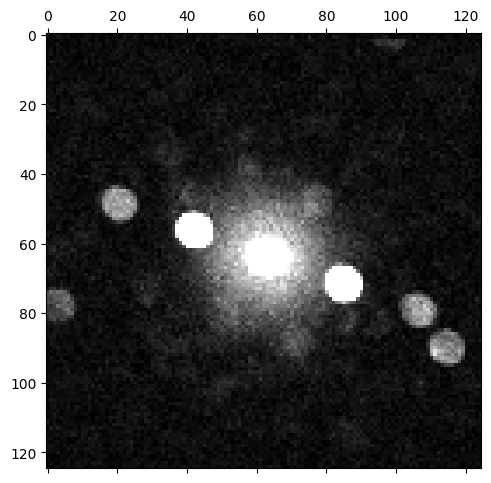

In [10]:
dp = datacube.data[10, 30]   # the diffraction pattern at scan position (10, 30)

py4DSTEM.show(dp)

You should see a bright central disk — the **direct beam**, electrons that passed through without scattering — surrounded by weaker **Bragg disks** from the gold lattice. Try changing `(10, 30)` to other positions and re-running.

Rather than editing numbers by hand, let's browse the whole dataset interactively:

## Browse the data interactively

Before running any analysis, it is *always* worth exploring a 4D-STEM dataset by hand. The cell below downloads a small interactive browser widget: **click or drag on the left (real-space) panel to move the electron probe**, and the right panel shows the diffraction pattern recorded at that position.

Each panel has its own contrast controls: the small histogram below the image shows the distribution of displayed intensities — **drag the two blue markers** to set the display window (it defaults to the 2%–98% intensity quantiles) — and the **power slider** compresses the dynamic range (diffraction spans many orders of magnitude, so powers well below 1 are usually best on the right panel).

Browsing builds intuition fast: where the sample is, how strongly it diffracts, whether the patterns shift on the detector, and what artifacts to look out for.

In [11]:
# Download the interactive 4D-STEM data browser widget.
import os, sys

if not os.path.exists('/content/browse_4dstem.py'):
    py4DSTEM.io.gdrive_download(
        id_ = 'https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c',
        destination = '/content/',
        filename = 'browse_4dstem.py',
    )
sys.path.append('/content')

# on Colab, third-party widgets need the custom widget manager enabled
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass   # not on Colab

from browse_4dstem import browse_4dstem

Downloading...
From (original): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c
From (redirected): https://drive.google.com/uc?id=1dFK5GZ8Eq9TX_ENjLp5P_K2pbsfbs00c&confirm=t&uuid=e8b364a5-1258-4f38-a843-ec451e80e0fb
To: /content/browse_4dstem.py
100%|██████████| 17.1k/17.1k [00:00<00:00, 10.2MB/s]


In [12]:
browse_4dstem(datacube.data)

A few things to notice as you move around:

- Some regions show *rings* of many disks at random angles — many small gold grains in different orientations.
- Some positions show a clean, symmetric single-crystal pattern — the probe is on one grain.
- Some positions show almost nothing but the direct beam — the probe is over the amorphous support only.

# Mean and max diffraction patterns

Two quick summary images tell us a lot about a dataset. The **mean** diffraction pattern (averaged over all probe positions) shows the dominant, persistent features. The **max** pattern (the brightest value each detector pixel ever reached) reveals Bragg disks even if they only lit up at a single probe position — a great way to see *all* the scattering at once.

Note the `scaling='log'` argument: diffraction data spans an enormous intensity range (the direct beam can be thousands of times brighter than the weakest disks), so we almost always compress the display with a log or power scale.

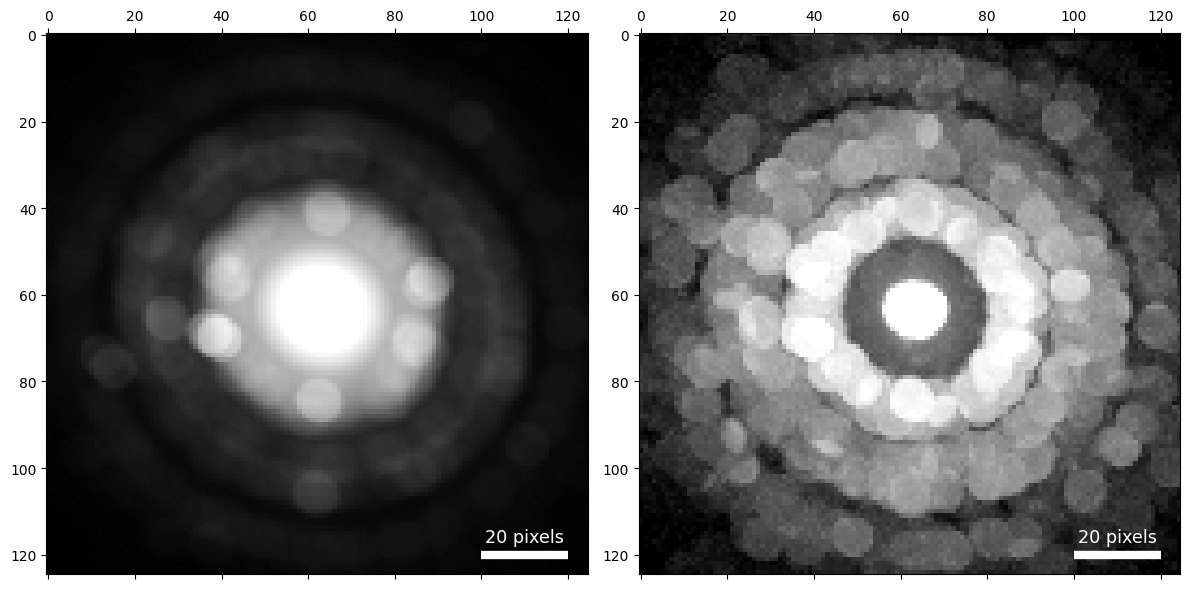

In [13]:
# compute
dp_mean = datacube.get_dp_mean()
dp_max = datacube.get_dp_max()

# show
py4DSTEM.show(
    [dp_mean, dp_max],
    scaling='log',
)

Results computed from a datacube are automatically stored in its *tree* — a small filesystem-like structure that keeps data and derived results together (and makes saving easy later). Let's look:

In [14]:
datacube.tree()

/
|---dp_mean
|---dp_max


In [15]:
# any stored result can be retrieved by name:
datacube.tree('dp_mean')

VirtualDiffraction( A 2-dimensional array of shape (125, 125) called 'dp_mean',
                    with dimensions:

                        dim0 = [0,1,2,...] pixels
                        dim1 = [0,1,2,...] pixels
)

# Virtual imaging

Virtual imaging is the simplest 4D-STEM analysis. Pick a region of the *detector* (a "virtual detector"), sum the electrons landing in that region at each probe position, and plot the result as an image over the scan. This reproduces a conventional STEM detector image, but the detector geometry can be chosen after the experiment, and changed as many times as we like.

Two classic choices:

- a **bright-field (BF)** detector: a disk over the direct beam. Regions that scatter strongly remove electrons from the direct beam and appear *dark*.
- an **annular dark-field (ADF)** detector: a ring around the direct beam that collects scattered electrons. Strongly scattering regions appear *bright*.

First we position a circular BF detector over the direct beam and check the geometry:

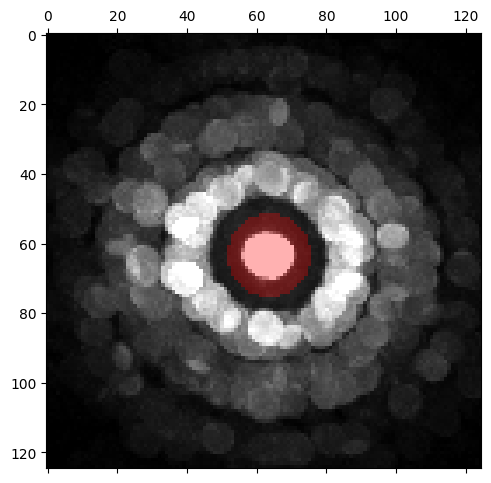

In [16]:
# set the detector geometry by hand
center = (63.5, 63.5)
radius = 12

# draw the detector on top of the max diffraction pattern
datacube.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = (center, radius),
)

100%|██████████| 8400/8400 [00:00<00:00, 20131.24it/s]


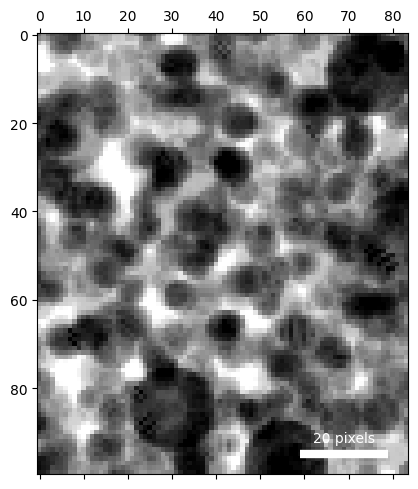

In [17]:
# compute the virtual bright-field image
datacube.get_virtual_image(
    mode = 'circle',
    geometry = (center, radius),
    name = 'bright_field',   # stored in the datacube's tree under this name
)

# show
py4DSTEM.show(datacube.tree('bright_field'))

The gold grains (strong scatterers) show up dark against the support. We can also find the direct beam programmatically instead of typing the center by hand — useful for scripts and larger workflows:

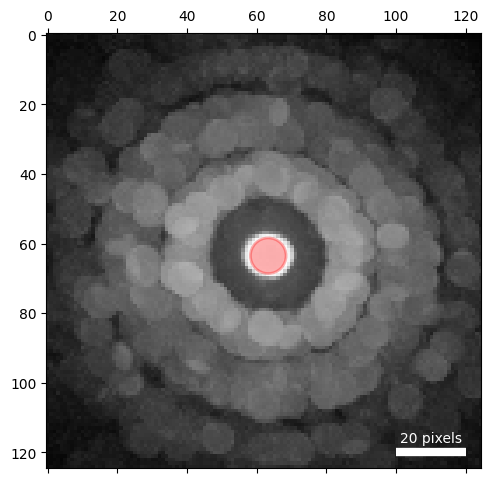

estimated probe radius = 5.12 pixels


In [18]:
# estimate the direct beam's position and radius from the mean pattern
probe_semiangle, probe_qx0, probe_qy0 = datacube.get_probe_size(
    dp_mean.data,
)

py4DSTEM.show(
    dp_max,
    scaling='log',
    vmin = 0,
    vmax = 1,
    circle = {
        'center': (probe_qx0, probe_qy0),
        'R': probe_semiangle,
        'alpha': 0.3,
        'fill': True,
    },
)

print(f'estimated probe radius = {probe_semiangle:.2f} pixels')

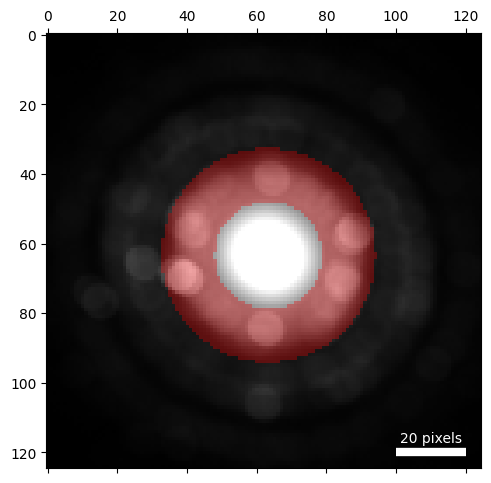

In [19]:
# an annular (ring-shaped) dark-field detector
center = probe_qx0, probe_qy0
radii = (probe_semiangle * 3, probe_semiangle * 6)

datacube.position_detector(
    mode = 'annular',
    geometry = (center, radii),
)

100%|██████████| 8400/8400 [00:00<00:00, 14411.43it/s]


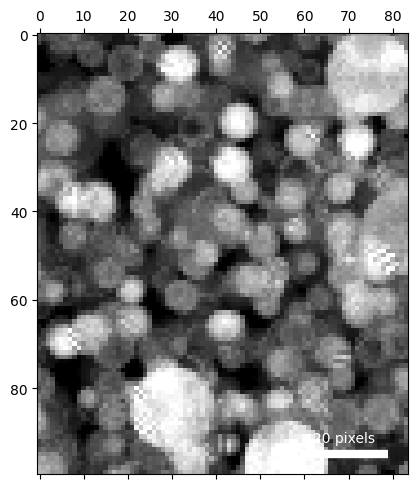

In [20]:
# compute and show the virtual ADF image
datacube.get_virtual_image(
    mode = 'annulus',
    geometry = (center, radii),
    name = 'annular_dark_field',
)

py4DSTEM.show(datacube.tree('annular_dark_field'))

Same sample, opposite contrast: the grains are now bright. Try re-browsing the data using the ADF image for navigation — it makes it much easier to see which patterns come from which grains:

In [21]:
browse_4dstem(
    datacube.data,
    nav_image = datacube.tree('annular_dark_field').data,
)

# Bragg disk detection

To measure strain or orientation we need the **precise position of every Bragg disk in every pattern**. py4DSTEM finds them by **template matching**:

1. Build a *template* — an image of the vacuum electron probe (what a disk looks like with no sample).
2. Turn the template into a cross-correlation *kernel*.
3. **Cross-correlate** the kernel with each diffraction pattern. Wherever the pattern locally "looks like" the template, the correlation has a sharp peak — and those peak positions are the disk positions.
4. Tune the detection parameters on a few test patterns, then run on all of them.

## Step 1: get a probe image

The best probe template comes from recording the probe over vacuum during your experiment. Here, we can do nearly as well: this scan contains a region with no gold particles (just the thin amorphous support), so averaging the patterns there gives a clean image of the probe.

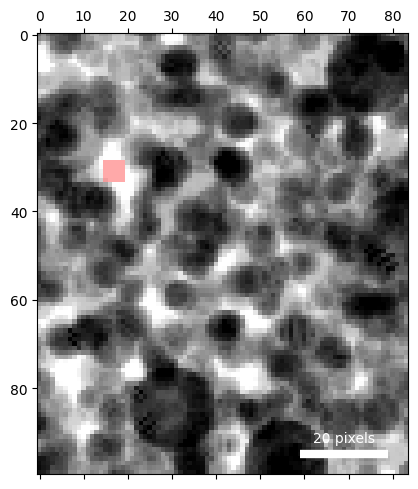

In [22]:
# select a vacuum region of the scan
mask = np.zeros(datacube.Rshape, dtype=bool)
mask[29:34, 15:20] = True

py4DSTEM.show(
    datacube.tree('bright_field'),
    mask = ~mask,
    mask_alpha = 0.667,
    mask_color = 'r',
)

100%|██████████| 24/24 [00:00<00:00, 90.32it/s] 


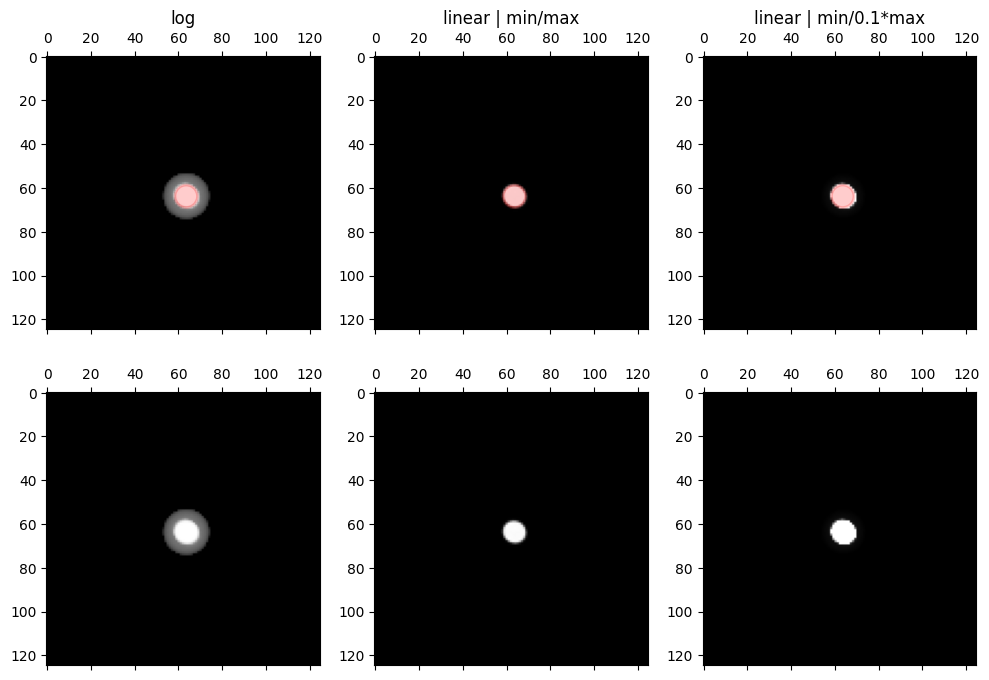

In [23]:
# average the patterns in that region into a probe image
probe = datacube.get_vacuum_probe(ROI=mask)

# and measure its size
alpha_pr, qx0_pr, qy0_pr = py4DSTEM.process.calibration.get_probe_size(probe.probe)

## Step 2: make the correlation kernel

The simplest kernel would be the probe image itself. Detection works noticeably better with one refinement: we surround the probe with a shallow *trench* of negative intensity. The negative ring penalizes positions where the template is slightly off-center, sharpening the correlation peak and "locking in" on the true disk center — it acts like an edge filter.

The kernel plot below shows this shape: a bright positive disk (center) with a negative moat around it. (The plot shows line cuts through the kernel center — note the dip below zero.)

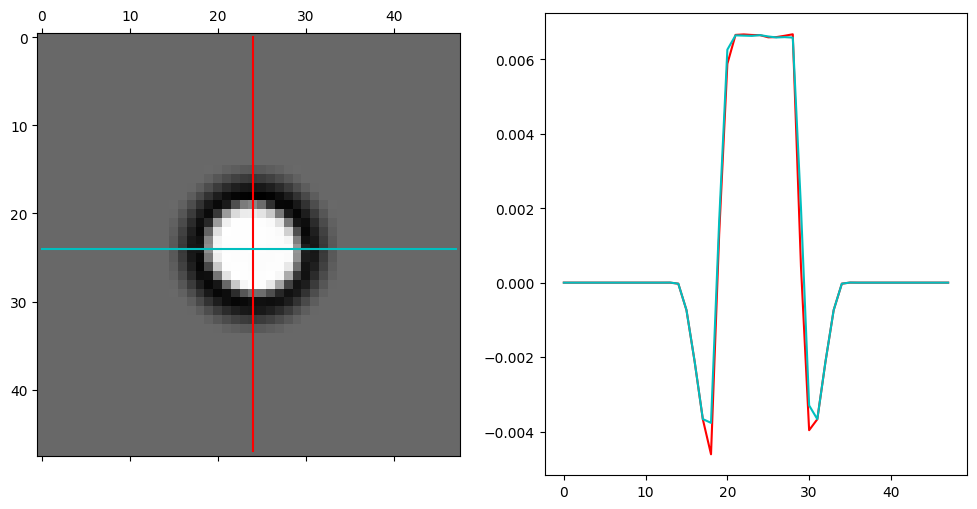

In [24]:
probe.get_kernel(
    mode = 'sigmoid',
    radii = (alpha_pr, 2 * alpha_pr),   # inner and outer radii of the negative trench
)

py4DSTEM.visualize.show_kernel(
    probe.kernel,
    R = 24, L = 24, W = 1,
)

## Step 3: test detection parameters on a few patterns

Do not run a detection on 4,000+ patterns before checking it on a few test patterns. We pick a few probe positions covering the different situations in the data — single grains, grain overlaps, support only — and inspect the detected disks visually.

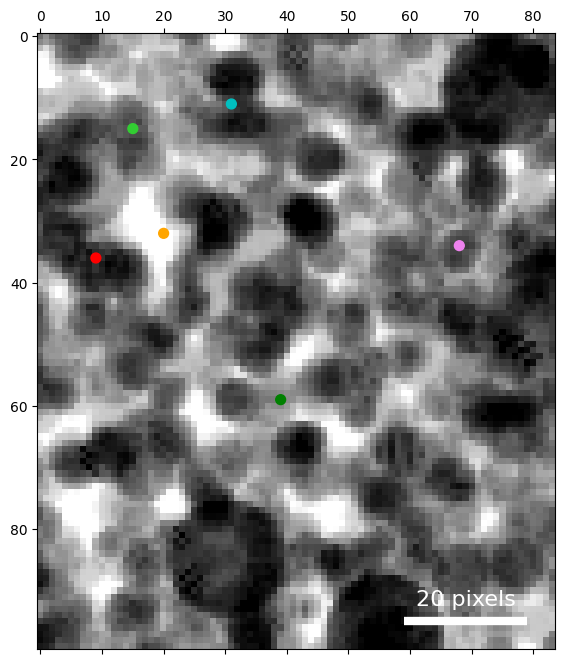

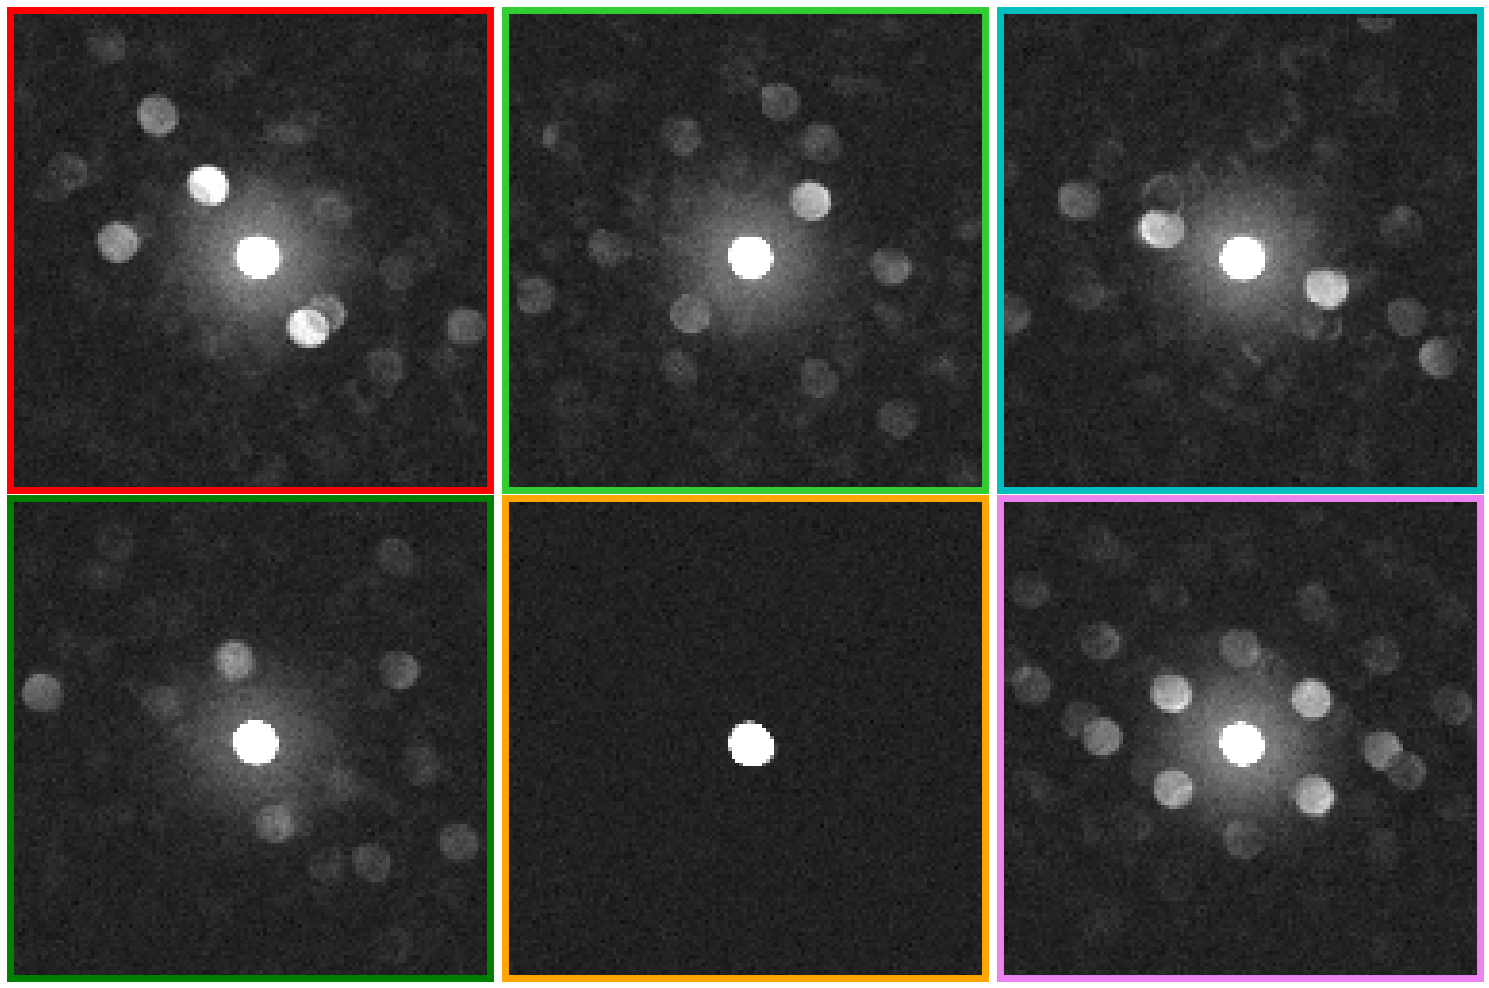

In [25]:
# choose test scan positions
rxs = 36, 15, 11, 59, 32, 34
rys = 9, 15, 31, 39, 20, 68

colors = ['r', 'limegreen', 'c', 'g', 'orange', 'violet']

# where are they in real space?
py4DSTEM.visualize.show_points(
    datacube.tree('bright_field'),
    x = rxs, y = rys,
    pointcolor = colors,
    figsize = (8, 8),
)

# and what do their diffraction patterns look like?
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: datacube[rxs[i], rys[i], :, :],
    H = 2, W = 3,
    axsize = (5, 5),
    intensity_range = 'absolute', vmin = 10, vmax = 500,
    scaling = 'power', power = 0.5,
    get_bordercolor = lambda i: colors[i],
)

The detection parameters below are the knobs you will tune on every new dataset. The most important ones:

- `minAbsoluteIntensity` — reject correlation peaks below this intensity (filters out noise);
- `minPeakSpacing` — if two peaks are closer than this (pixels), keep only the brighter one;
- `sigma` — small Gaussian blur applied to the correlation before peak-finding (suppresses pixel noise);
- `subpixel` — how precisely to locate each peak: `'poly'` (fast parabolic fit, ~0.1 px) or `'multicorr'` (Fourier upsampling, ~0.01 px — used when we need high precision, e.g. strain mapping);
- `maxNumPeaks` — keep at most this many peaks per pattern, brightest first.

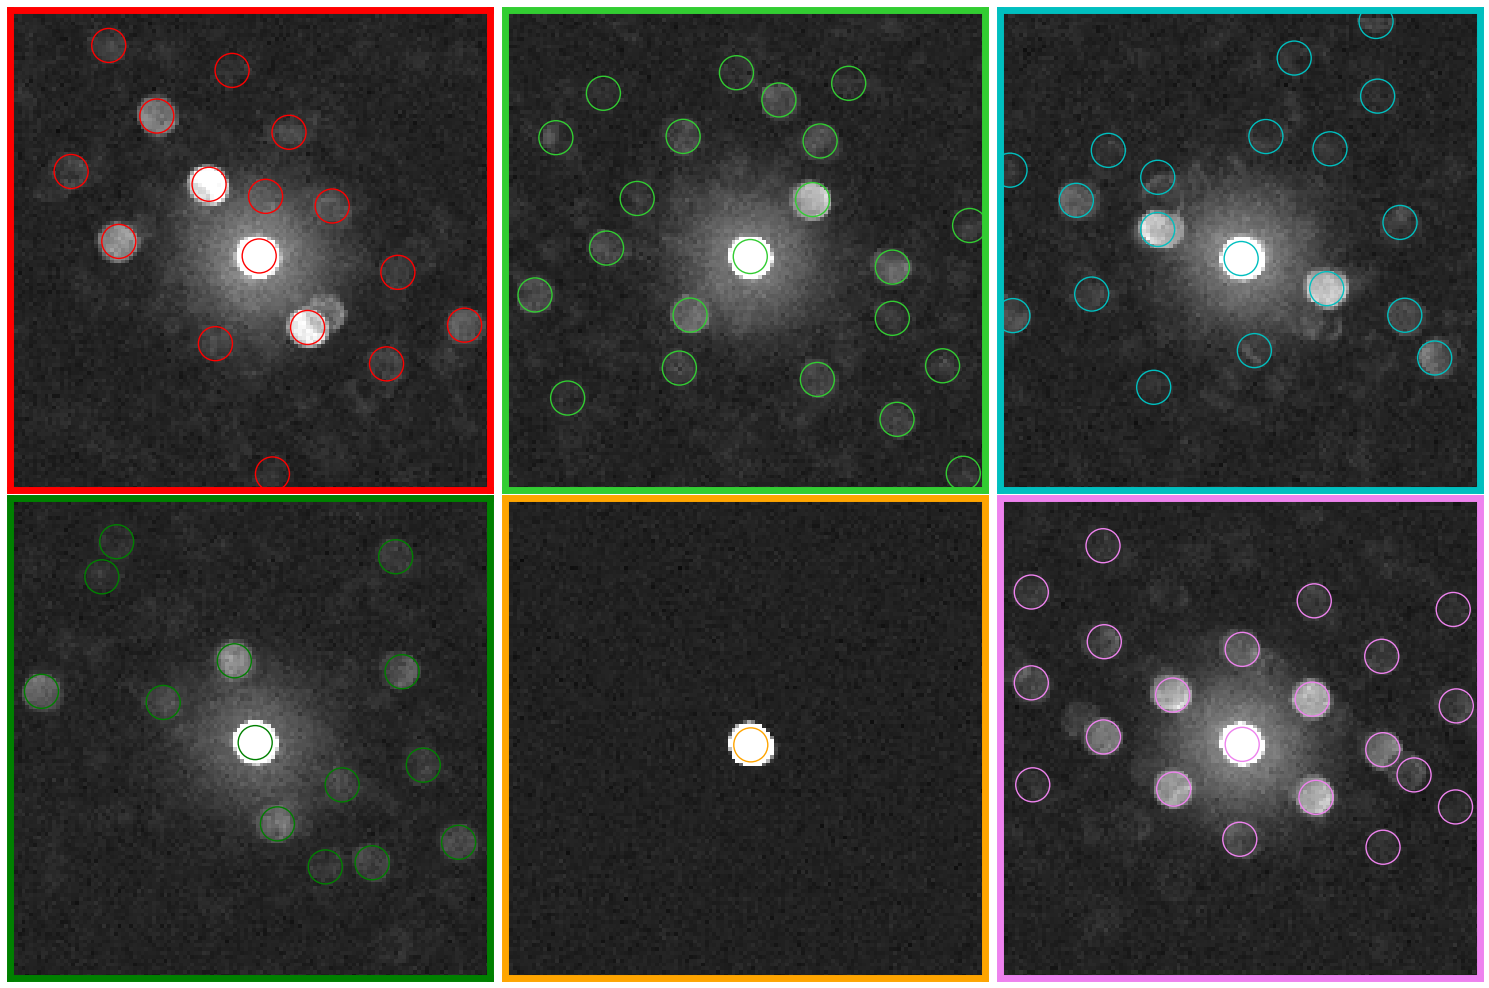

In [26]:
detect_params = {
    'minAbsoluteIntensity': 3,
    'minRelativeIntensity': 0,
    'minPeakSpacing': 2,
    'edgeBoundary': 2,
    'sigma': 1,
    'maxNumPeaks': 60,
    'subpixel': 'poly',
    'corrPower': 1.0,
}

# detect on just the test positions
disks_selected = datacube.find_Bragg_disks(
    data = (rxs, rys),
    template = probe.kernel,
    **detect_params,
)

# overlay the detected disks on the test patterns
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i: datacube[rxs[i], rys[i], :, :],
    H = 2, W = 3,
    axsize = (5, 5),
    intensity_range = 'absolute', vmin = 10, vmax = 500,
    scaling = 'power', power = 0.5,
    get_bordercolor = lambda i: colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 600,
)

Check each test pattern: is every visible disk circled? Are there circles on empty background (false positives)? Adjust the parameters and re-run this cell until you are happy — this iterate-and-look loop is exactly how you will work with your own data.

## Step 4: find all the disks

In [27]:
braggpeaks = datacube.find_Bragg_disks(
    template = probe.kernel,
    **detect_params,
)

Finding Bragg Disks: 100%|██████████| 8.40k/8.40k [00:18<00:00, 462DP/s]


# The Bragg vector map

We just measured hundreds of thousands of disk positions. Just as the mean/max patterns summarized the raw data, the **Bragg vector map (BVM)** summarizes the detection: a 2D histogram of every detected disk position, weighted by intensity. It shows, at a glance, all the scattering angles present in the dataset — for our polycrystalline gold, rings of spots at the gold lattice spacings.

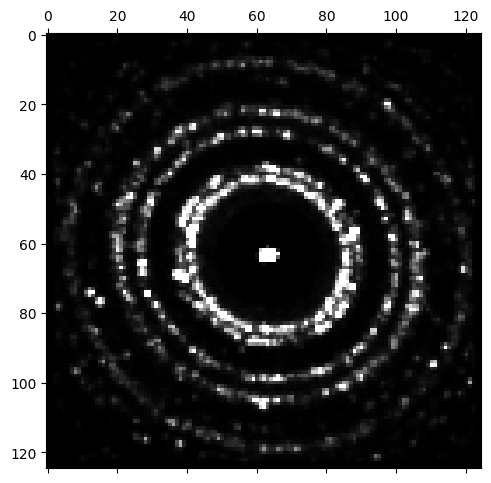

In [28]:
bvm = braggpeaks.histogram(mode='raw')

py4DSTEM.show(bvm)

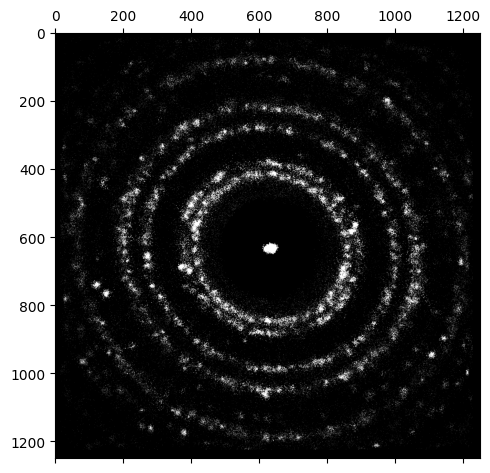

In [29]:
# The histogram can be sampled more finely than the detector pixels, since the
# subpixel disk positions carry more information -- try it:
bvm_upsampled = braggpeaks.histogram(
    mode = 'raw',
    sampling = 10,
)

py4DSTEM.show(bvm_upsampled)

In the upsampled map you can see that each peak is slightly diffuse — a mix of real physics (grains at slightly different orientations) and measurement error. Calibrating and sharpening these measurements (centering, elliptical distortion, rotation) is the next step in any quantitative workflow, and it is where the strain and orientation notebooks pick up.

# Save your results

py4DSTEM saves any analysis object — or a datacube's whole tree of results — to HDF5. Here we save everything *derived from* the datacube (virtual images, probe, Bragg peaks) without the raw data itself:

In [30]:
filepath_save = dirpath + 'analysis_basics.h5'

py4DSTEM.save(
    filepath_save,
    datacube,
    tree = None,   # save everything under the datacube, but not the datacube itself
    mode = 'o',    # overwrite if the file exists
)

# inspect the file we just wrote
py4DSTEM.print_h5_tree(filepath_save)

100%|██████████| 8400/8400 [00:01<00:00, 4858.02it/s]

/
|---4DSTEM_simulation
    |---annular_dark_field
    |---braggvectors
    |   |---_v_uncal
    |---bright_field
    |---dp_max
    |---dp_mean
    |---probe




*(Remember: `/content/` is wiped when the Colab session ends — download the file from the Files sidebar if you want to keep it.)*

# Recap and what's next

In this notebook you have:

1. loaded a 4D-STEM datacube and learned its `(scan_row, scan_col, k_row, k_col)` structure;
2. browsed diffraction patterns interactively;
3. built virtual bright-field and dark-field images with after-the-fact "virtual detectors";
4. constructed a probe template + correlation kernel, tuned the disk detection on test patterns, and measured every Bragg disk in the dataset;
5. summarized the measurement in a Bragg vector map and saved your results.

The follow-on notebooks build directly on these skills: **strain mapping** (precise disk positions → local lattice distortion), **orientation mapping** (disk patterns → crystal orientation), **phase + orientation + strain** combined, and **flowline mapping** of soft-matter orientation.